# Week 3 — Feature Engineering & Baseline Models

## Step 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn as sns
print(sns.__version__)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                              confusion_matrix, classification_report, roc_auc_score, roc_curve)
import joblib
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
sns.set_style('whitegrid')

print('Libraries loaded successfully!')

0.13.2
Libraries loaded successfully!


In [2]:
pip install --upgrade seaborn

Note: you may need to restart the kernel to use updated packages.


In [3]:
df = pd.read_csv('hr_attrition_cleaned.csv')

In [4]:
df = pd.read_csv('hr_attrition_cleaned.csv')
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Shape: 1470 rows, 31 columns


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Yes,11,3,1,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,No,23,4,4,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Yes,15,3,2,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Yes,11,3,3,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,No,12,3,4,1,6,3,3,2,2,2,2


---
# PART 1 — FEATURE ENGINEERING
---

In [5]:
df_fe = df.copy()

# Avoid division by zero for employees with 0 total working years
df_fe['TenureRatio'] = df_fe['YearsAtCompany'] / df_fe['TotalWorkingYears'].replace(0, 1)

df_fe['IncomePerJobLevel'] = df_fe['MonthlyIncome'] / df_fe['JobLevel']

satisfaction_cols = ['JobSatisfaction', 'EnvironmentSatisfaction',
                     'RelationshipSatisfaction', 'WorkLifeBalance']
df_fe['SatisfactionScore'] = df_fe[satisfaction_cols].mean(axis=1)

df_fe['PromotionGap'] = df_fe['YearsAtCompany'] - df_fe['YearsSinceLastPromotion']

new_features = ['TenureRatio', 'IncomePerJobLevel', 'SatisfactionScore', 'PromotionGap']
df_fe[new_features].describe().T

,count,mean,std,min,25%,50%,75%,max
TenureRatio,1470.0,0.678074,0.328093,0.0,0.411765,0.80,1.000000,1.0
IncomePerJobLevel,1470.0,2973.800986,770.640517,1009.0,2394.125000,2856.50,3478.833333,4999.0
SatisfactionScore,1470.0,2.730952,0.505815,1.0,2.500000,2.75,3.000000,4.0
PromotionGap,1470.0,4.820408,4.847756,0.0,1.000000,4.00,7.000000,36.0


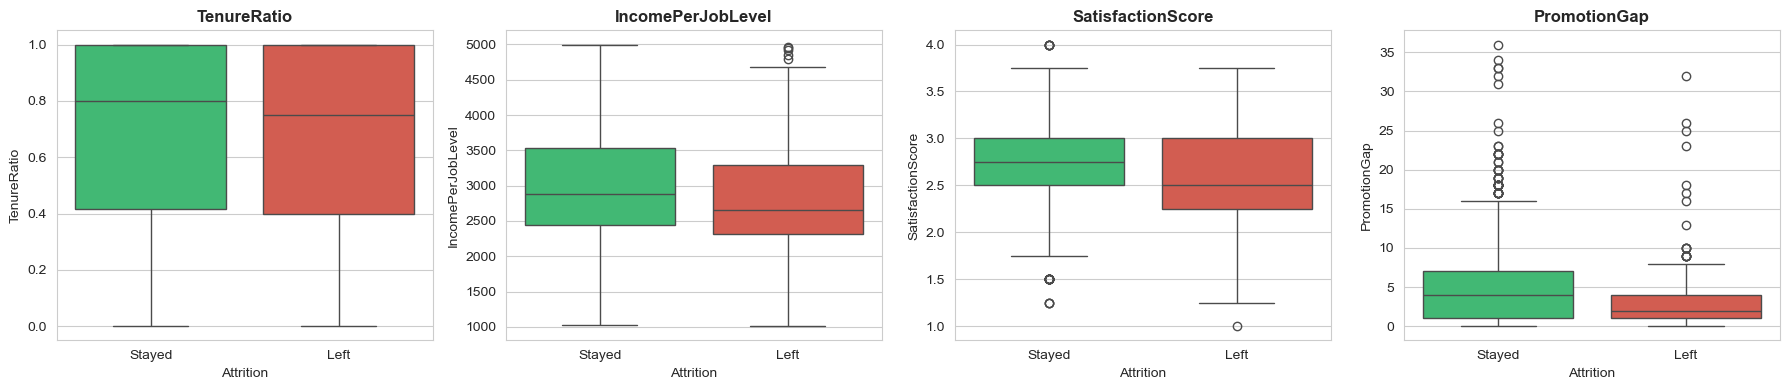

In [6]:

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for i, col in enumerate(new_features):
    sns.boxplot(data=df_fe, x='Attrition', y=col, hue='Attrition',
                palette=['#2ecc71', '#e74c3c'], legend=False, ax=axes[i])
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xticklabels(['Stayed', 'Left'])
plt.tight_layout()
plt.savefig('new_features_vs_attrition.png', dpi=150, bbox_inches='tight')
plt.show()

---
# PART 2 — ENCODING & SCALING
---

## Step 4 — Encode Categorical Variables



In [7]:

df_fe['OverTime'] = df_fe['OverTime'].map({'Yes': 1, 'No': 0})
df_fe['Gender'] = df_fe['Gender'].map({'Male': 1, 'Female': 0})

# One-hot encode the remaining nominal categorical columns
nominal_cols = ['Department', 'JobRole', 'MaritalStatus', 'EducationField', 'BusinessTravel']
df_encoded = pd.get_dummies(df_fe, columns=nominal_cols, drop_first=True)

print(f"Shape before encoding: {df_fe.shape}")
print(f"Shape after one-hot encoding: {df_encoded.shape}")
df_encoded.head()

Shape before encoding: (1470, 35)
Shape after one-hot encoding: (1470, 49)


,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,TenureRatio,IncomePerJobLevel,SatisfactionScore,PromotionGap,Department_Research & Development,Department_Sales,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely
0,41,1,1102,1,2,2,0,94,3,2,4,5993,19479,8,1,11,3,1,0,8,0,1,6,4,0,5,0.750000,2996.5,2.00,6,False,True,False,False,False,False,False,False,True,False,False,True,True,False,False,False,False,False,True
1,49,0,279,8,1,3,1,61,2,2,2,5130,24907,1,0,23,4,4,1,10,3,3,10,7,1,7,1.000000,2565.0,3.00,9,True,False,False,False,False,False,False,True,False,False,True,False,True,False,False,False,False,True,False
2,37,1,1373,2,2,4,1,92,2,1,3,2090,2396,6,1,15,3,2,0,7,3,3,0,0,0,0,0.000000,2090.0,3.00,0,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,True,False,False,True
3,33,0,1392,3,4,4,0,56,3,1,3,2909,23159,1,1,11,3,3,0,8,3,3,8,7,3,0,1.000000,2909.0,3.25,5,True,False,False,False,False,False,False,True,False,False,True,False,True,False,False,False,False,True,False
4,27,0,591,2,1,1,1,40,3,1,2,3468,16632,9,0,12,3,4,1,6,3,3,2,2,2,2,0.333333,3468.0,2.50,0,True,False,False,True,False,False,False,False,False,False,True,False,False,False,True,False,False,False,True


## Step 5 — Define Features (X) and Target (y)

In [8]:
X = df_encoded.drop(columns=['Attrition'])
y = df_encoded['Attrition']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nTarget distribution:\n{y.value_counts()}")
print(f"\nFeature columns:\n{X.columns.tolist()}")

X shape: (1470, 48)
y shape: (1470,)

Target distribution:
Attrition
0    1233
1     237
Name: count, dtype: int64

Feature columns:
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'TenureRatio', 'IncomePerJobLevel', 'SatisfactionScore', 'PromotionGap', 'Department_Research & Development', 'Department_Sales', 'JobRole_Human Resources', 'JobRole_Laboratory Technician', 'JobRole_Manager', 'JobRole_Manufacturing Director', 'JobRole_Research Director', 'JobRole_Research Scientist', 'JobRole_Sales Executive', 'JobRole_Sales Representative', 'MaritalStatus_Married', 'MaritalStatus_

## Step 6 — Train-Test Split (80/20)



In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train set: {X_train.shape[0]} rows ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test set:  {X_test.shape[0]} rows ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nTrain target distribution:\n{y_train.value_counts(normalize=True).round(3)}")
print(f"\nTest target distribution:\n{y_test.value_counts(normalize=True).round(3)}")

Train set: 1176 rows (80.0%)
Test set:  294 rows (20.0%)

Train target distribution:
Attrition
0    0.838
1    0.162
Name: proportion, dtype: float64

Test target distribution:
Attrition
0    0.84
1    0.16
Name: proportion, dtype: float64


## Step 7 — Scale Numerical Features



In [10]:
numeric_cols = ['Age', 'DailyRate', 'DistanceFromHome', 'HourlyRate', 'MonthlyIncome',
                'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'TotalWorkingYears',
                'TrainingTimesLastYear', 'YearsAtCompany', 'YearsInCurrentRole',
                'YearsSinceLastPromotion', 'YearsWithCurrManager',
                'TenureRatio', 'IncomePerJobLevel', 'SatisfactionScore', 'PromotionGap']

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

print("Scaling complete. Sample of scaled training data:")
X_train_scaled[numeric_cols].describe().T[['mean', 'std']].round(2)

Scaling complete. Sample of scaled training data:


,mean,std
Age,-0.0,1.0
DailyRate,0.0,1.0
DistanceFromHome,-0.0,1.0
HourlyRate,-0.0,1.0
MonthlyIncome,-0.0,1.0
MonthlyRate,0.0,1.0
NumCompaniesWorked,-0.0,1.0
PercentSalaryHike,-0.0,1.0
TotalWorkingYears,-0.0,1.0
TrainingTimesLastYear,0.0,1.0


---
# PART 3 — BASELINE MODEL
---

## Step 8 — Train Baseline Model (Logistic Regression)



In [11]:
baseline_model = LogisticRegression(max_iter=1000, random_state=42)
baseline_model.fit(X_train_scaled, y_train)

print("Baseline Logistic Regression model trained successfully!")

Baseline Logistic Regression model trained successfully!


## Step 9 — Evaluate Baseline Model



In [12]:
y_pred = baseline_model.predict(X_test_scaled)
y_pred_proba = baseline_model.predict_proba(X_test_scaled)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("=" * 45)
print("BASELINE MODEL PERFORMANCE (Logistic Regression)")
print("=" * 45)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")
print("=" * 45)

BASELINE MODEL PERFORMANCE (Logistic Regression)
Accuracy:  0.8741
Precision: 0.6923
Recall:    0.3830
F1-Score:  0.4932
ROC-AUC:   0.8082


In [13]:
print("Full Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=['Stayed', 'Left']))

Full Classification Report:

              precision    recall  f1-score   support

      Stayed       0.89      0.97      0.93       247
        Left       0.69      0.38      0.49        47

    accuracy                           0.87       294
   macro avg       0.79      0.68      0.71       294
weighted avg       0.86      0.87      0.86       294



## Step 10 — Confusion Matrix

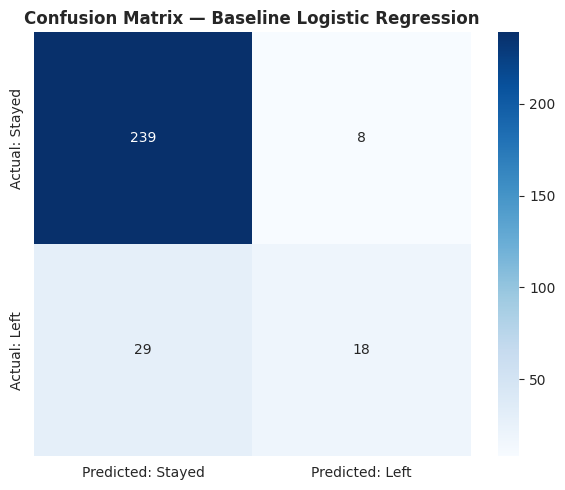

True Negatives (correctly predicted 'Stayed'):  239
False Positives (predicted 'Left', actually stayed): 8
False Negatives (predicted 'Stayed', actually left): 29  <-- most costly error for HR
True Positives (correctly predicted 'Left'):    18


In [12]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: Stayed', 'Predicted: Left'],
            yticklabels=['Actual: Stayed', 'Actual: Left'])
plt.title('Confusion Matrix — Baseline Logistic Regression', fontweight='bold')
plt.tight_layout()
plt.savefig('baseline_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives (correctly predicted 'Stayed'):  {tn}")
print(f"False Positives (predicted 'Left', actually stayed): {fp}")
print(f"False Negatives (predicted 'Stayed', actually left): {fn}  <-- most costly error for HR")
print(f"True Positives (correctly predicted 'Left'):    {tp}")

## Step 11 — ROC Curve

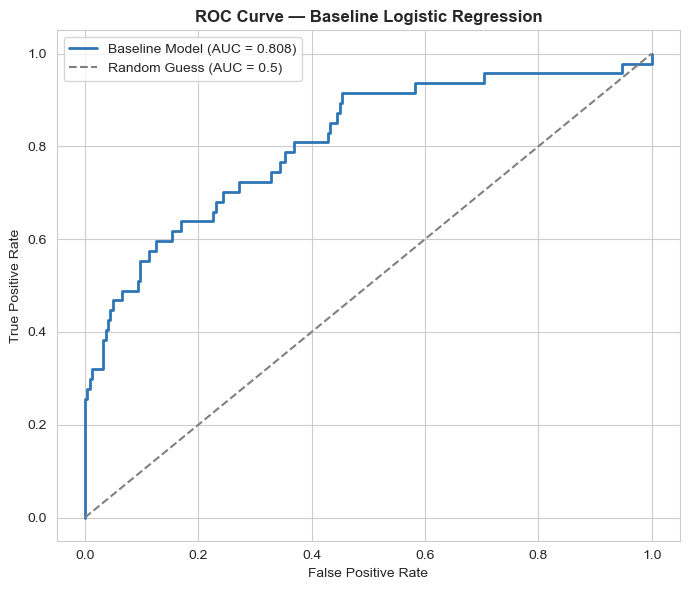

In [14]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='#2E75B6', linewidth=2, label=f'Baseline Model (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Guess (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Baseline Logistic Regression', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('baseline_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 12 — Feature Importance (Logistic Regression Coefficients)

Top 15 most influential features (by absolute coefficient):
                          Feature  Coefficient
                         OverTime     1.799934
 BusinessTravel_Travel_Frequently     1.549785
    JobRole_Laboratory Technician     1.321622
        JobRole_Research Director    -0.990950
                    MonthlyIncome     0.937886
     JobRole_Sales Representative     0.888371
             EducationField_Other    -0.809436
             MaritalStatus_Single     0.700847
     BusinessTravel_Travel_Rarely     0.675286
               NumCompaniesWorked     0.534386
Department_Research & Development    -0.523531
                         JobLevel    -0.517638
          JobRole_Human Resources     0.516126
                   JobInvolvement    -0.494763
          YearsSinceLastPromotion     0.446428


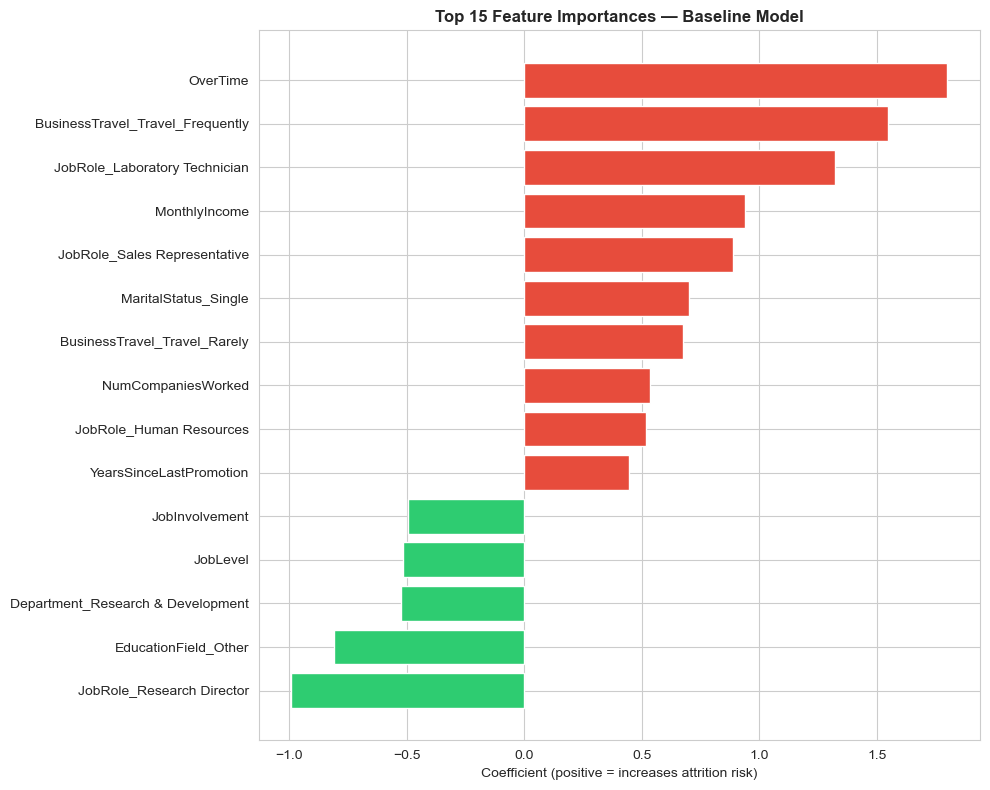

In [15]:
coef_df = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Coefficient': baseline_model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

print("Top 15 most influential features (by absolute coefficient):")
print(coef_df.head(15).to_string(index=False))

plt.figure(figsize=(10, 8))
top15 = coef_df.head(15).sort_values('Coefficient')
colors = ['#e74c3c' if x > 0 else '#2ecc71' for x in top15['Coefficient']]
plt.barh(top15['Feature'], top15['Coefficient'], color=colors)
plt.xlabel('Coefficient (positive = increases attrition risk)')
plt.title('Top 15 Feature Importances — Baseline Model', fontweight='bold')
plt.tight_layout()
plt.savefig('baseline_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

---
# PART 4 — SAVE ARTIFACTS FOR WEEK 4
---

In [16]:

df_encoded.to_csv('hr_attrition_features.csv', index=False)

joblib.dump(scaler, 'scaler.pkl')
joblib.dump(baseline_model, 'baseline_logistic_model.pkl')

X_train_scaled.to_csv('X_train.csv', index=False)
X_test_scaled.to_csv('X_test.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv', index=False)

print("Saved for Week 4:")
print("  - hr_attrition_features.csv  (full feature-engineered + encoded dataset)")
print("  - scaler.pkl                  (fitted StandardScaler)")
print("  - baseline_logistic_model.pkl (baseline model)")
print("  - X_train.csv / X_test.csv / y_train.csv / y_test.csv (saved split)")

Saved for Week 4:
  - hr_attrition_features.csv  (full feature-engineered + encoded dataset)
  - scaler.pkl                  (fitted StandardScaler)
  - baseline_logistic_model.pkl (baseline model)
  - X_train.csv / X_test.csv / y_train.csv / y_test.csv (saved split)
